In [1]:
import numpy as np
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, cohen_kappa_score, balanced_accuracy_score, matthews_corrcoef, f1_score
import matplotlib.pyplot as plt
import pandas as pd

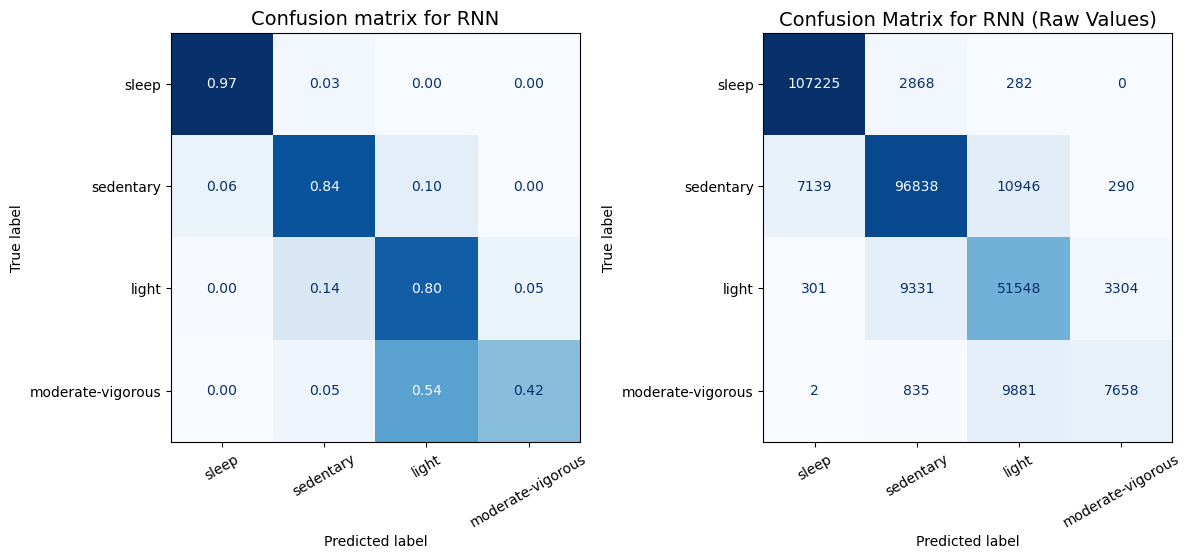

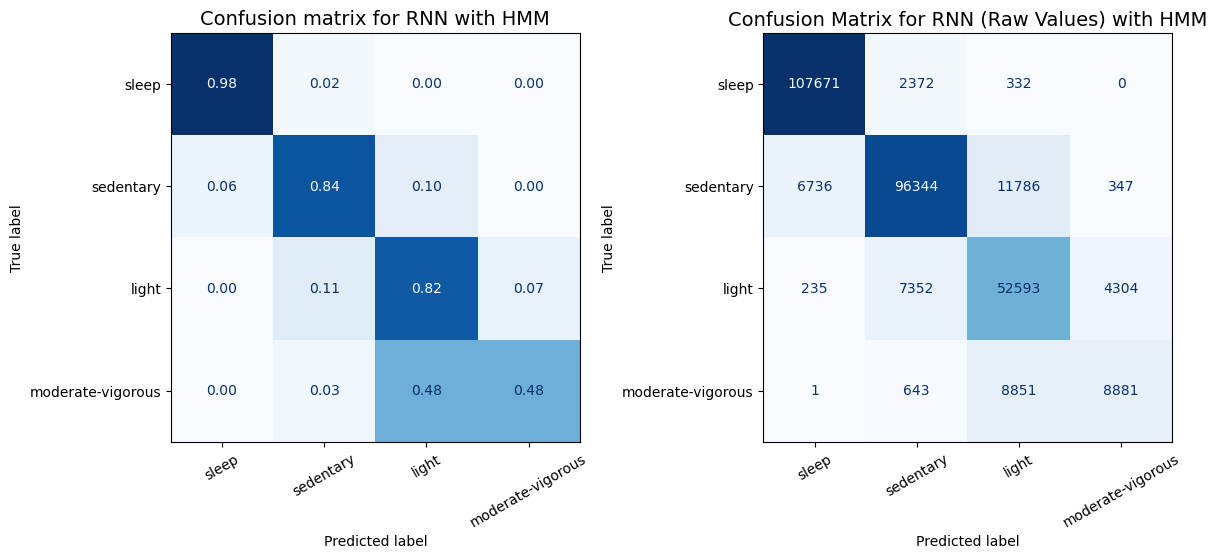

In [20]:
#RNN with no HMM
PAorder = ['sleep', 'sedentary','light','moderate-vigorous']

RNN_pred = np.load("final_pred_test.npz")
RNN_pred_hmm = np.load("final_pred_hmm.npz")

fig, ax = plt.subplots(1,2, figsize = (12,7))
ConfusionMatrixDisplay.from_predictions(  RNN_pred['true_labels'], RNN_pred['model_preds'], display_labels=PAorder,
                                         normalize = 'true', cmap = 'Blues',values_format = '.2f', ax = ax[0], colorbar=False)
ax[0].set_title('Confusion matrix for RNN', fontsize=14)
ax[0].tick_params(axis='x', rotation=30)
ConfusionMatrixDisplay.from_predictions( RNN_pred['true_labels'], RNN_pred['model_preds'], display_labels=PAorder,
                                           ax = ax[1], colorbar = False, cmap = 'Blues')
ax[1].set_title('Confusion Matrix for RNN (Raw Values)', fontsize = 14)
ax[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1,2, figsize = (12,7))
ConfusionMatrixDisplay.from_predictions(  RNN_pred_hmm['true_labels'], RNN_pred_hmm['model_preds'], display_labels=PAorder,
                                         normalize = 'true', cmap = 'Blues',values_format = '.2f', ax = ax[0], colorbar=False)
ax[0].set_title('Confusion matrix for RNN with HMM', fontsize=14)
ax[0].tick_params(axis='x', rotation=30)
ConfusionMatrixDisplay.from_predictions( RNN_pred_hmm['true_labels'], RNN_pred_hmm['model_preds'], display_labels=PAorder,
                                           ax = ax[1], colorbar = False, cmap = 'Blues')
ax[1].set_title('Confusion Matrix for RNN (Raw Values) with HMM', fontsize = 14)
ax[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

#### Now CNN

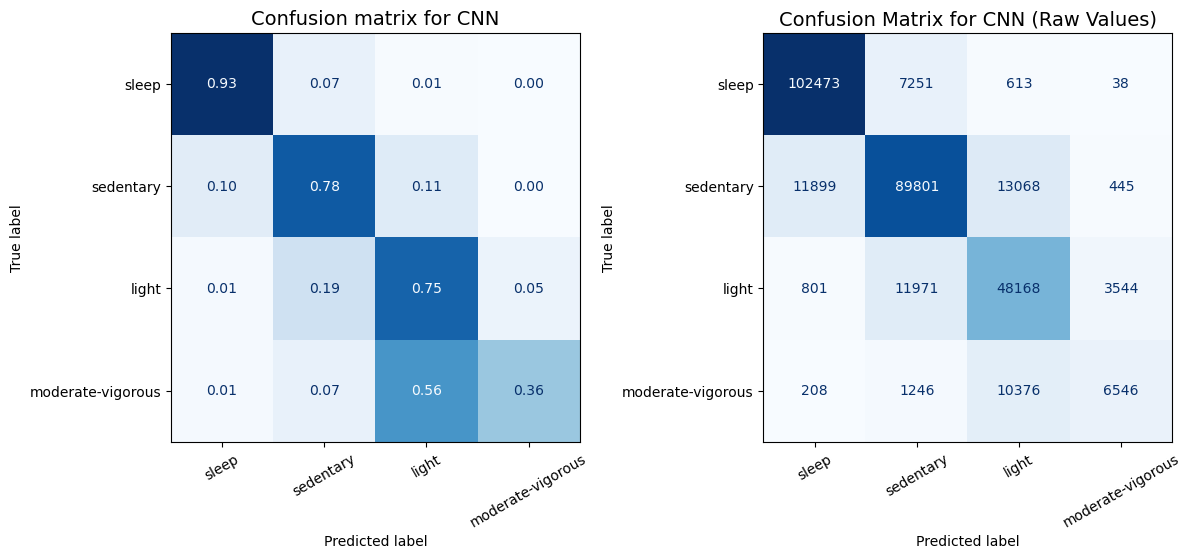

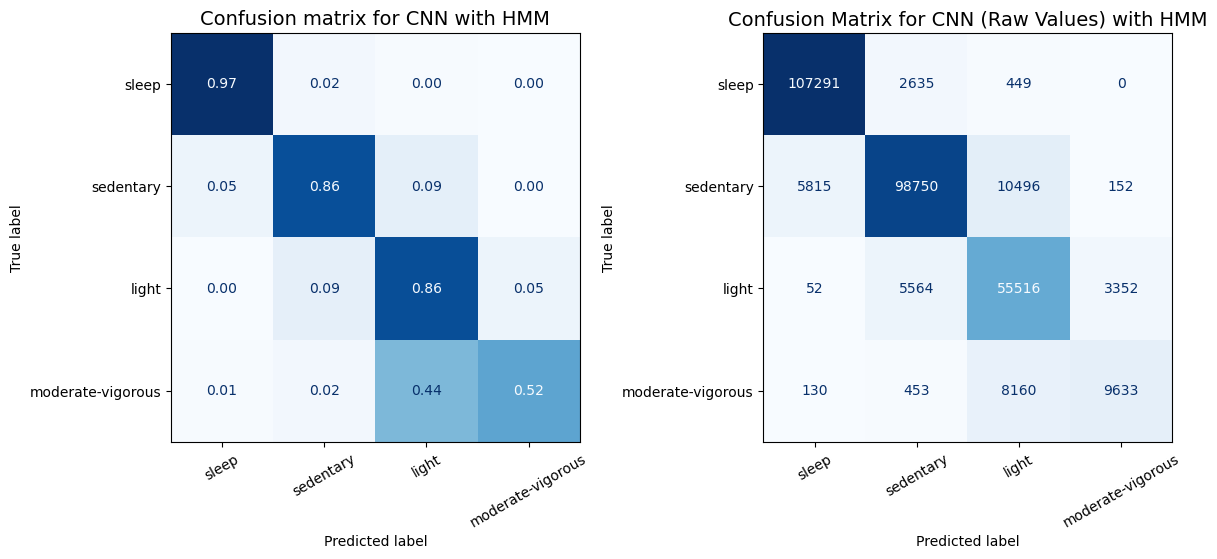

In [22]:
CNN = np.load("final_pred_CNN_test.npz")
CNN_HMM = np.load("final_pred_CNN_test_hmm.npz")

fig, ax = plt.subplots(1,2, figsize = (12,7))
ConfusionMatrixDisplay.from_predictions( CNN['true_labels'], CNN['model_preds'], display_labels=PAorder,
                                         normalize = 'true', cmap = 'Blues',values_format = '.2f', ax = ax[0], colorbar=False)
ax[0].set_title('Confusion matrix for CNN', fontsize=14)
ax[0].tick_params(axis='x', rotation=30)
ConfusionMatrixDisplay.from_predictions(  CNN['true_labels'], CNN['model_preds'], display_labels=PAorder,
                                           ax = ax[1], colorbar = False, cmap = 'Blues', values_format='d')
ax[1].set_title('Confusion Matrix for CNN (Raw Values)', fontsize = 14)
ax[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()


fig, ax = plt.subplots(1,2, figsize = (12,7))
ConfusionMatrixDisplay.from_predictions( CNN_HMM['true_labels'], CNN_HMM['model_preds'], display_labels=PAorder,
                                         normalize = 'true', cmap = 'Blues',values_format = '.2f', ax = ax[0], colorbar=False)
ax[0].set_title('Confusion matrix for CNN with HMM', fontsize=14)
ax[0].tick_params(axis='x', rotation=30)
ConfusionMatrixDisplay.from_predictions( CNN_HMM['true_labels'], CNN_HMM['model_preds'], display_labels=PAorder,
                                           ax = ax[1], colorbar = False, cmap = 'Blues', values_format = 'd')
ax[1].set_title('Confusion Matrix for CNN (Raw Values) with HMM', fontsize = 14)
ax[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

In [29]:
pred = pd.read_csv("final_pred_test_ds.csv")
# pred = pred.rename(columns = { 'hmm_preds':'model_preds'})
# pred

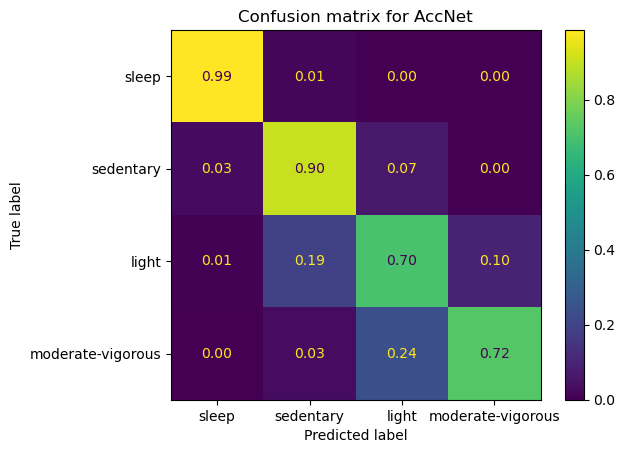

Metrics report for the AccNet: 

                   precision    recall  f1-score   support

            light       0.76      0.70      0.73     16539
moderate-vigorous       0.61      0.72      0.66      3850
        sedentary       0.91      0.90      0.91     41291
            sleep       0.97      0.99      0.98     36012

         accuracy                           0.89     97692
        macro avg       0.81      0.83      0.82     97692
     weighted avg       0.89      0.89      0.89     97692

 test/bacc: 0.829
  test/phi: 0.836
test/kappa: 0.836
test/f1: 0.819


In [30]:

ConfusionMatrixDisplay.from_predictions( pred['true_labels'], pred['model_preds'], labels=PAorder,
                                         normalize = 'true', values_format = '.2f')
plt.title('Confusion matrix for AccNet')
plt.show()
print('Metrics report for the AccNet: \n')
report = classification_report( pred['true_labels'], pred['model_preds'], digits=2)
print(report)

bacc = balanced_accuracy_score( pred['true_labels'], pred['model_preds'])
kappa = cohen_kappa_score( pred['true_labels'], pred['model_preds'])
phi = matthews_corrcoef(pred['true_labels'], pred['model_preds'])
f1 = f1_score(pred['true_labels'], pred['model_preds'], average = 'macro')

print(f" test/bacc: {bacc:.3f}")
print(f"  test/phi: {phi:.3f}")
print(f"test/kappa: {kappa:.3f}")
print(f"test/f1: {f1:.3f}")

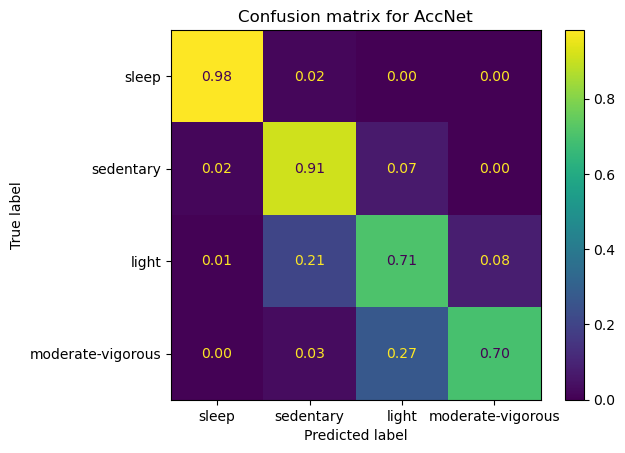

Metrics report for the AccNet: 

                   precision    recall  f1-score   support

            light       0.75      0.71      0.73     16539
moderate-vigorous       0.65      0.70      0.67      3850
        sedentary       0.90      0.91      0.90     41291
            sleep       0.98      0.98      0.98     36012

         accuracy                           0.89     97692
        macro avg       0.82      0.82      0.82     97692
     weighted avg       0.89      0.89      0.89     97692

 test/bacc: 0.823
  test/phi: 0.837
test/kappa: 0.837
test/f1: 0.820


In [35]:
# val
pred = pd.read_csv("final_pred_test.csv")
ConfusionMatrixDisplay.from_predictions( pred['true_labels'], pred['model_preds'], labels=PAorder,
                                         normalize = 'true', values_format = '.2f')
plt.title('Confusion matrix for AccNet')
plt.show()
print('Metrics report for the AccNet: \n')
report = classification_report( pred['true_labels'], pred['model_preds'], digits=2)
print(report)

bacc = balanced_accuracy_score( pred['true_labels'], pred['model_preds'])
kappa = cohen_kappa_score( pred['true_labels'], pred['model_preds'])
phi = matthews_corrcoef(pred['true_labels'], pred['model_preds'])
f1 = f1_score(pred['true_labels'], pred['model_preds'], average = 'macro')

print(f" test/bacc: {bacc:.3f}")
print(f"  test/phi: {phi:.3f}")
print(f"test/kappa: {kappa:.3f}")
print(f"test/f1: {f1:.3f}")

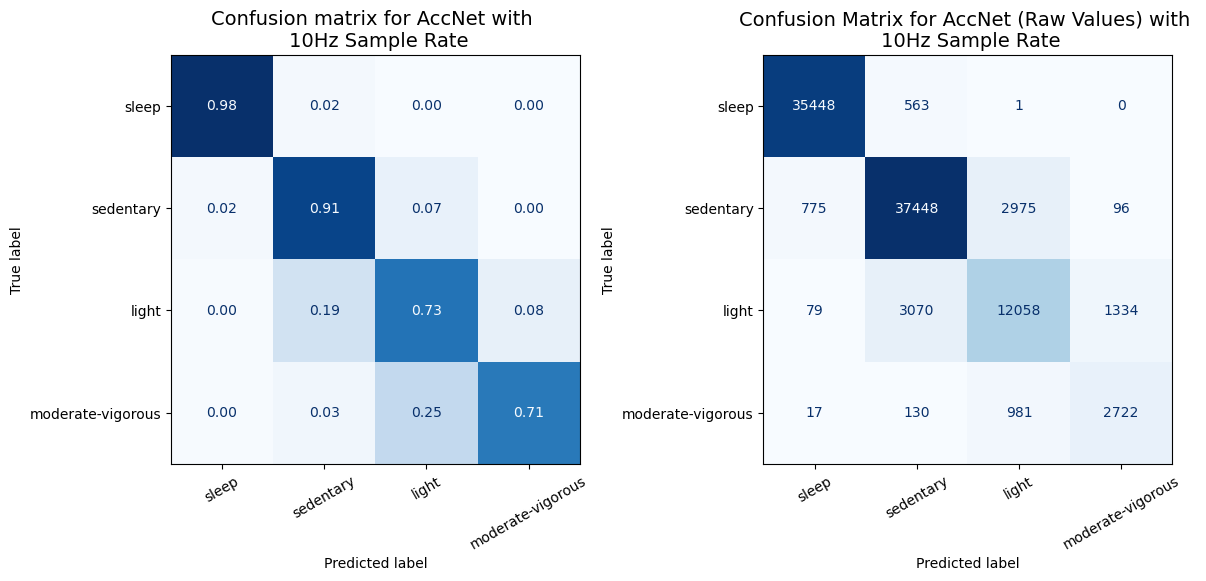

In [4]:
# Side by Side Normalised and true values for confusion matrices
pred = pd.read_csv("final_pred_test_test2_Best.csv")
fig, ax = plt.subplots(1,2, figsize = (12,7))
ConfusionMatrixDisplay.from_predictions( pred['true_labels'], pred['model_preds'], labels=PAorder,
                                         normalize = 'true', cmap = 'Blues',values_format = '.2f', ax = ax[0], colorbar=False)
ax[0].set_title('Confusion matrix for AccNet with \n 10Hz Sample Rate', fontsize=14)
ax[0].tick_params(axis='x', rotation=30)
ConfusionMatrixDisplay.from_predictions( pred['true_labels'], pred['model_preds'], labels=PAorder,
                                           ax = ax[1], colorbar = False, cmap = 'Blues')
ax[1].set_title('Confusion Matrix for AccNet (Raw Values) with \n 10Hz Sample Rate', fontsize = 14)
ax[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

## 10 Class problem

In [23]:
pred = pd.read_csv("final_pred_test_ten_hmm.csv").rename(columns = {"hmm_preds": "model_preds"})
pred.head(10)

,true_labels,model_preds
0,sleep,sleep
1,sleep,sleep
2,sleep,sleep
3,sleep,sleep
4,sleep,sleep
5,sleep,sleep
6,sleep,sleep
7,sleep,sleep
8,sleep,sleep
9,sleep,sleep


In [2]:
# Ordering 
HARorder = ['sleep', 'sitting','standing','household-chores','manual-work','walking','mixed-activity','vehicle','sports','bicycling']

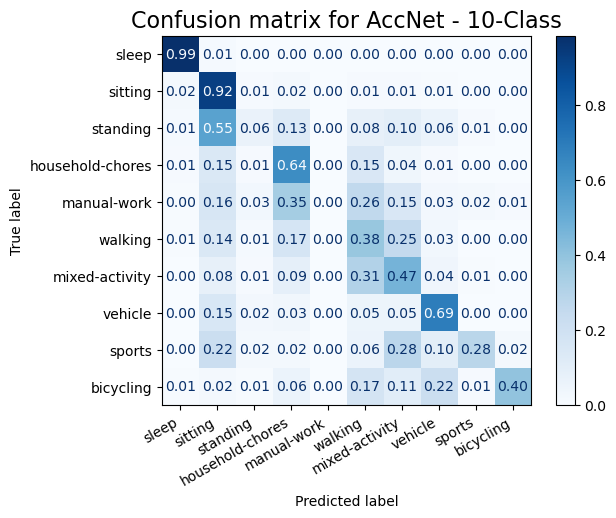

Metrics report for the AccNet: 



c:\Users\Finla\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Finla\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Finla\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                  precision    recall  f1-score   support

       bicycling       0.86      0.40      0.54       753
household-chores       0.62      0.64      0.63      6752
     manual-work       0.00      0.00      0.00       636
  mixed-activity       0.34      0.47      0.40      3217
         sitting       0.88      0.92      0.90     37377
           sleep       0.97      0.99      0.98     36012
          sports       0.59      0.28      0.38       509
        standing       0.22      0.06      0.10      2775
         vehicle       0.73      0.69      0.71      3841
         walking       0.42      0.38      0.40      5825

        accuracy                           0.83     97697
       macro avg       0.56      0.48      0.50     97697
    weighted avg       0.82      0.83      0.82     97697

 test/bacc: 0.483
  test/phi: 0.760
test/kappa: 0.760
test/f1: 0.503


In [11]:
pred = pd.read_csv("final_pred_test_ten_w_ds.csv")
ConfusionMatrixDisplay.from_predictions( pred['true_labels'], pred['model_preds'], labels=HARorder,
                                         normalize = 'true', values_format = '.2f',cmap = 'Blues')
plt.title('Confusion matrix for AccNet - 10-Class', fontsize = 16)
plt.xticks(rotation=30, ha = 'right')
plt.show()
print('Metrics report for the AccNet: \n')
report = classification_report( pred['true_labels'], pred['model_preds'], digits=2)
print(report)

bacc = balanced_accuracy_score( pred['true_labels'], pred['model_preds'])
kappa = cohen_kappa_score( pred['true_labels'], pred['model_preds'])
phi = matthews_corrcoef(pred['true_labels'], pred['model_preds'])
f1 = f1_score(pred['true_labels'], pred['model_preds'], average = 'macro')

print(f" test/bacc: {bacc:.3f}")
print(f"  test/phi: {phi:.3f}")
print(f"test/kappa: {kappa:.3f}")
print(f"test/f1: {f1:.3f}")

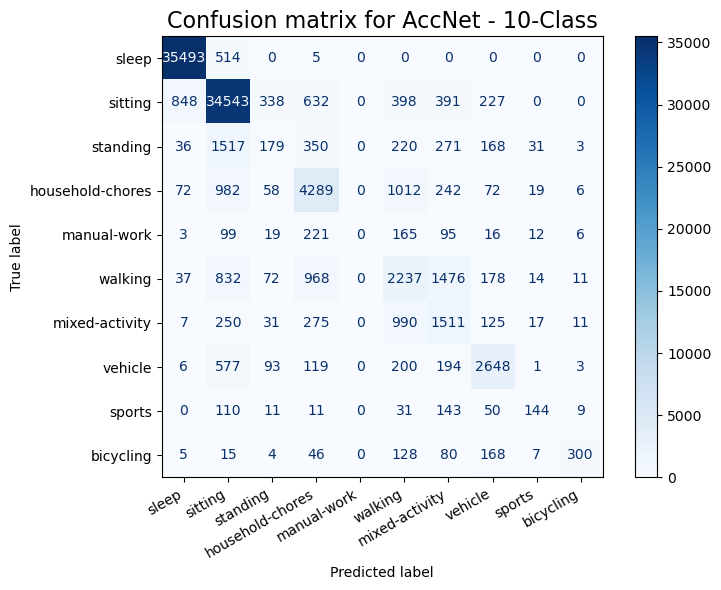

In [16]:
pred = pd.read_csv("final_pred_test_ten_w_ds.csv")

fig, ax = plt.subplots(figsize=(8,6)) 

ConfusionMatrixDisplay.from_predictions(
    pred['true_labels'], 
    pred['model_preds'], 
    labels=HARorder,
    values_format='d',
    cmap='Blues',
    ax=ax 
)

plt.title('Confusion matrix for AccNet - 10-Class', fontsize=16)
plt.xticks(rotation=30, ha='right')

# (Optional) Adjust layout so labels don't get cut off
plt.tight_layout() 

plt.show()

## Participant demographic analysis ##

In [27]:
meta_data = pd.read_csv('data\capture24\metadata.csv')
metrics_pp = pd.read_csv("Participant_Metrics_Summary.csv")

In [28]:
#Gets just participants 101-151
meta_data_test = meta_data.iloc[-51:].drop(columns = ["pid"], axis = 1)
meta_data_test = meta_data_test.reset_index(drop=True)
master = pd.merge(metrics_pp, meta_data_test, left_index = True, right_index=True)
master


,Participant_ID,Balanced_Accuracy,Macro_F1,age,sex
0,101,0.775118,0.800489,53+,F
1,102,0.571665,0.585189,38-52,M
2,103,0.701989,0.739801,18-29,M
3,104,0.660654,0.646081,18-29,F
4,105,0.779637,0.821976,18-29,F
5,106,0.890947,0.865690,18-29,F
6,107,0.930892,0.936625,38-52,F
7,108,0.725900,0.742615,38-52,M
8,109,0.763676,0.676052,18-29,F
9,110,0.811269,0.737548,18-29,F


In [58]:
#find average BACC and F1 in...

#Male and gender
by_gender = master.groupby('sex')[["Balanced_Accuracy", "Macro_F1"]].mean()

#Age 
by_age = master.groupby('age')[["Balanced_Accuracy", "Macro_F1"]].std()

both_mean = master.groupby(['age', 'sex'])[["Balanced_Accuracy", "Macro_F1"]].mean()

both_std = master.groupby(['age', 'sex'])[["Balanced_Accuracy", "Macro_F1"]].std()
print(by_gender)
print(both_mean)
both_std


     Balanced_Accuracy  Macro_F1
sex                             
F             0.803771  0.789978
M             0.768416  0.778168
           Balanced_Accuracy  Macro_F1
age   sex                             
18-29 F             0.792432  0.774465
      M             0.816363  0.832760
30-37 F             0.796553  0.808811
      M             0.749269  0.749336
38-52 F             0.800277  0.780515
      M             0.715052  0.731669
53+   F             0.833266  0.813084
      M             0.751416  0.753929


Balanced_Accuracy  Macro_F1
age   sex                             
18-29 F             0.069179  0.084930
      M             0.073513  0.067664
30-37 F             0.072262  0.072518
      M             0.141275  0.131128
38-52 F             0.104923  0.100511
      M             0.138282  0.141325
53+   F             0.074204  0.080862
      M             0.184112  0.189366

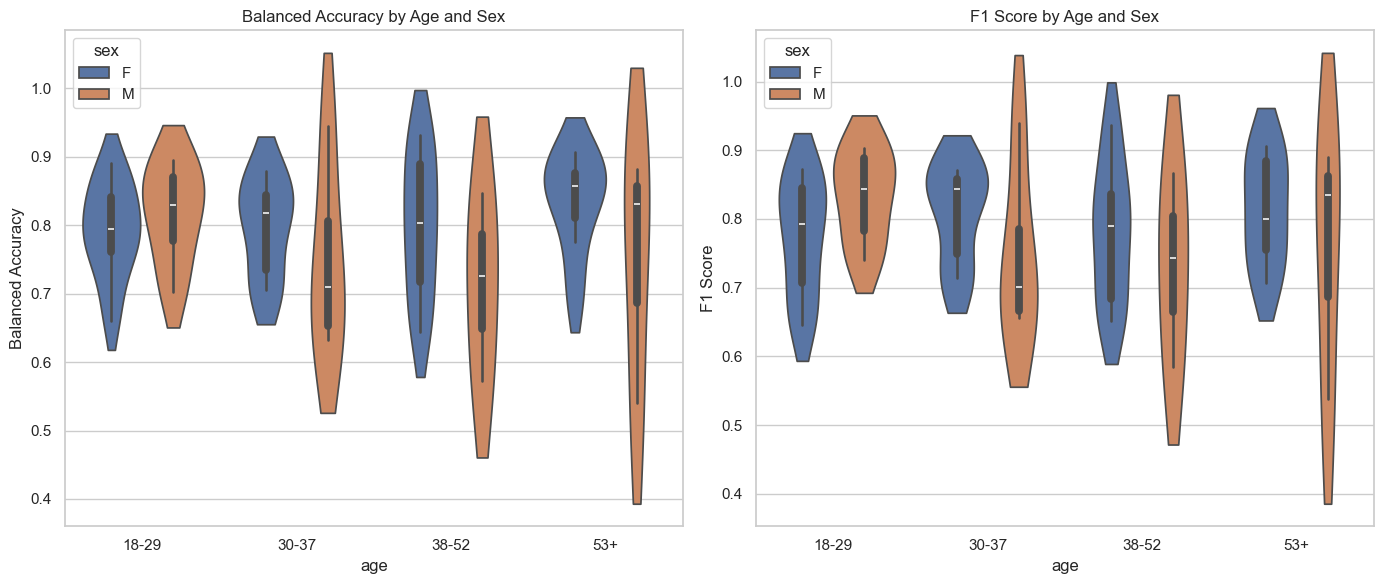

In [62]:

age_order = ['18-29', '30-37', '38-52', '53+']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.violinplot(
    data=master, 
    x='age', 
    y='Balanced_Accuracy', 
    hue='sex', 
    order=age_order, 
    cut=1, 
    ax=axes[0]
)
axes[0].set_title('Balanced Accuracy by Age and Sex')
axes[0].set_ylabel('Balanced Accuracy')

sns.violinplot(
    data=master, 
    x='age', 
    y='Macro_F1', 
    hue='sex', 
    order=age_order, 
    cut=1, 
    ax=axes[1]
)
axes[1].set_title('F1 Score by Age and Sex')
axes[1].set_ylabel('F1 Score')

# 4. Clean up the layout and display
plt.tight_layout()
plt.show()